Importing the data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")

In [3]:
df.head()

,Unnamed: 0,Disease Description,Scenario,Note,Polished Note,Abbreviated Note,Role,dial,polished_dial
0,0,PAIN IN LEFT KNEE,ROLE: Orthopedic Specialist\n\n1) Medical Outc...,**1. Subjective:**\n\n **Chief Complaint (CC...,**1. Subjective:**\n\n **Chief Complaint (CC...,**1. Subjective:**\n\n **CC:**\n - L knee ...,Orthopedic Specialist,**Doctor:** Hello! It’s good to see you today....,[doctor]: Hello! It’s good to see you today. H...
1,1,PAIN IN LEFT KNEE,ROLE: General Physician\n\n- **Medical Outcome...,**1. Subjective:**\n\n - **Chief Complaint (...,**1. Subjective:**\n\n - **Chief Complaint (...,**1. Subjective:**\n\n - **CC:** Pain in L k...,General Physician,**CHIEF COMPLAINT**\n\nPain in left knee.\n\n*...,"[doctor] Hi there, how are you today?\n\n[pati..."
2,2,PAIN IN LEFT KNEE,ROLE: Family Medicine Physician \n\n** 1) Medi...,#####\n**1. Subjective:**\n\n**Chief Complaint...,**1. Subjective:**\n\n**Chief Complaint (CC):*...,**1. Subjective:**\n\n**CC:**\nSevere R hip pa...,Family Medicine Physician,"[doctor] Good morning, how are you doing today...","[doctor] Good morning, how are you doing today..."
3,3,PAIN IN LEFT KNEE,ROLE: Orthopedic Specialist\n\n**Scenario:**\n...,**1. Subjective:**\n\n**Chief Complaint (CC):*...,**1. Subjective:**\n\n**Chief Complaint (CC):*...,**1. Subjective:**\n\n**CC:** \nModerate knee...,Orthopedic Specialist,[doctor] Good morning! How are you feeling tod...,[doctor] Good morning! How are you feeling tod...
4,4,PAIN IN LEFT KNEE,ROLE: Orthopedic Specialist\n\n** Medical Outc...,#####\n**1. Subjective:**\n\n**Chief Complaint...,#####\n**1. Subjective:**\n\n**Chief Complaint...,#####\n**1. Subjective:**\n\n**CC:** \nModera...,Orthopedic Specialist,"[doctor]: Hello Mr. Doe, how are you doing tod...","[doctor]: Hello Mr. Doe, how are you doing tod..."


In [4]:
df["polished_dial"][0]

"[doctor]: Hello! It’s good to see you today. How can I help you?\n\n[patient]: Hi, Doctor. I’ve been having a lot of pain in my left knee.\n\n[doctor]: I’m sorry to hear that. Can you tell me more about the pain and how long it’s been going on?\n\n[patient]: Sure. It's been pretty bad, moderate to severe pain, for the last three weeks.\n\n[doctor]: Hmm, that sounds uncomfortable. Is there anything specific that makes the pain worse?\n\n[patient]: Yes, physical activities really make it worse. Walking, climbing stairs, standing for long periods—it all makes it more painful.\n\n[doctor]: I see. Have you noticed any swelling or stiffness in the knee?\n\n[patient]: Yes, there’s occasional swelling and it’s really stiff, especially in the mornings.\n\n[doctor]: Alright, any other symptoms you’ve noticed? Fever, weight loss, anything like that?\n\n[patient]: No, no fever or weight loss.\n\n[doctor]: How about chest pain or palpitations? Anything unusual with your heart?\n\n[patient]: No, my

**Loading and using transformers**

In [ ]:
! pip install transformers

In [5]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

c:\Users\SAFIR2023\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [6]:
# 1. Convert all entries in 'polished_dial' to strings, replacing NaN with an empty string
df['polished_dial'] = df['polished_dial'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['polished_dial'] = df['polished_dial'].str.replace('\n', ' ')

In [7]:
df["polished_dial"][0]

"[doctor]: Hello! It’s good to see you today. How can I help you?  [patient]: Hi, Doctor. I’ve been having a lot of pain in my left knee.  [doctor]: I’m sorry to hear that. Can you tell me more about the pain and how long it’s been going on?  [patient]: Sure. It's been pretty bad, moderate to severe pain, for the last three weeks.  [doctor]: Hmm, that sounds uncomfortable. Is there anything specific that makes the pain worse?  [patient]: Yes, physical activities really make it worse. Walking, climbing stairs, standing for long periods—it all makes it more painful.  [doctor]: I see. Have you noticed any swelling or stiffness in the knee?  [patient]: Yes, there’s occasional swelling and it’s really stiff, especially in the mornings.  [doctor]: Alright, any other symptoms you’ve noticed? Fever, weight loss, anything like that?  [patient]: No, no fever or weight loss.  [doctor]: How about chest pain or palpitations? Anything unusual with your heart?  [patient]: No, my heart seems fine. No 

**Calculating token avg for SOURCE with doctor and patient included**

In [8]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'polished_dial'
df['token_count'] = df['polished_dial'].apply(count_tokens)

# 6. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'polished_dial': {avg_token_count}")


Average token count in 'polished_dial': 1127.3607374190333


**Counting token avg for SOURCE without doctor and patient included**

In [9]:
# Assuming your dataset is already loaded into a DataFrame called df
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
# 1. Convert all entries in 'polished_dial' to strings, replacing NaN with an empty string
df['polished_dial'] = df['polished_dial'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['polished_dial'] = df['polished_dial'].str.replace('\n', ' ')

In [10]:
import pandas as pd
from transformers import BertTokenizer
import re


# 3. Remove speaker tags like "[doctor]:" and "[patient]:"
def remove_speaker_tags(text):
    # Using regex to remove any pattern that matches "[doctor]:" or "[patient]:"
    cleaned_text = re.sub(r'\[doctor\]:|\[patient\]:', '', text, flags=re.IGNORECASE)
    return cleaned_text.strip()  # Strip any leading or trailing whitespace

df['polished_dial'] = df['polished_dial'].apply(remove_speaker_tags)

# 4. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 5. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 6. Apply the token counting function to each row in 'polished_dial'
df['token_count'] = df['polished_dial'].apply(count_tokens)

# 7. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'polished_dial' after removing speaker tags: {avg_token_count}")


Average token count in 'polished_dial' after removing speaker tags: 1024.405879422023


**AVG token count for TARGET**

In [11]:
df["Polished Note"][0]

"**1. Subjective:**\n\n   **Chief Complaint (CC):**\n   - Pain in the left knee, moderate to severe, lasting for 3 weeks.\n\n   **History of Present Illness (HPI):**\n   - The patient, a 52-year-old Caucasian male named John Smith, presents with complaints of moderate to severe pain in the left knee that has persisted for the past three weeks. The pain is associated with occasional swelling and stiffness, particularly pronounced in the mornings. The symptoms are exacerbated by physical activity and have a significant impact on daily activities, including walking, climbing stairs, and prolonged standing.\n\n   **Review of Systems (ROS):**\n   - Musculoskeletal: Positive for knee pain, swelling, and stiffness.\n   - General: Negative for fever or weight loss.\n   - Cardiovascular: Negative for chest pain or palpitations.\n   - Constitutional: Sleep disruption due to knee pain; otherwise stable.\n\n**2. Objective:**\n\n   **Vital Signs:**\n   - Blood Pressure: 128/82 mmHg\n   - Heart Rate

In [12]:
# 1. Convert all entries in 'Polished Note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
df['Polished Note'] = df['Polished Note'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['Polished Note'] = df['Polished Note'].str.replace('\n', '')
df['Polished Note'] = df['Polished Note'].str.replace('*', '')

In [13]:
df["Polished Note"][0]

"1. Subjective:   Chief Complaint (CC):   - Pain in the left knee, moderate to severe, lasting for 3 weeks.   History of Present Illness (HPI):   - The patient, a 52-year-old Caucasian male named John Smith, presents with complaints of moderate to severe pain in the left knee that has persisted for the past three weeks. The pain is associated with occasional swelling and stiffness, particularly pronounced in the mornings. The symptoms are exacerbated by physical activity and have a significant impact on daily activities, including walking, climbing stairs, and prolonged standing.   Review of Systems (ROS):   - Musculoskeletal: Positive for knee pain, swelling, and stiffness.   - General: Negative for fever or weight loss.   - Cardiovascular: Negative for chest pain or palpitations.   - Constitutional: Sleep disruption due to knee pain; otherwise stable.2. Objective:   Vital Signs:   - Blood Pressure: 128/82 mmHg   - Heart Rate: 72 bpm   - Respiratory Rate: 16 breaths per minute   - Tem

In [14]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'polished_dial'
df['token_count'] = df['Polished Note'].apply(count_tokens)

# 6. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'Polished Note': {avg_token_count}")

Average token count in 'Polished Note': 631.1894369706029


**AVG of sentences for TARGET**

In [15]:
# 1. Convert all entries in 'Polished Note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
df['Polished Note'] = df['Polished Note'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['Polished Note'] = df['Polished Note'].str.replace('\n', '')
df['Polished Note'] = df['Polished Note'].str.replace('*', '')

In [16]:
def count_sentences(text):
    # Split the text by sentence-ending punctuation (., ?, !)
    sentences = re.split(r'[.!?:]+', text)
    # Filter out empty strings that might result from splitting
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

# 4. Apply the sentence counting function to each row in 'polished_dial'
df['sentence_count'] = df['Polished Note'].apply(count_sentences)

# 5. Calculate the average sentence count
avg_sentence_count = df['sentence_count'].mean()

# Print the average sentence count
print(f"Average sentence count in 'Polished Note': {avg_sentence_count}")


Average sentence count in 'Polished Note': 69.3982062780269


**Calculating the size**

In [17]:
len(df)

10035

**Calculating the frequency of SOURCE**

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# 1. Convert all entries in 'Polished Note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
df['polished_dial'] = df['polished_dial'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['polished_dial'] = df['polished_dial'].str.replace('\n', '')

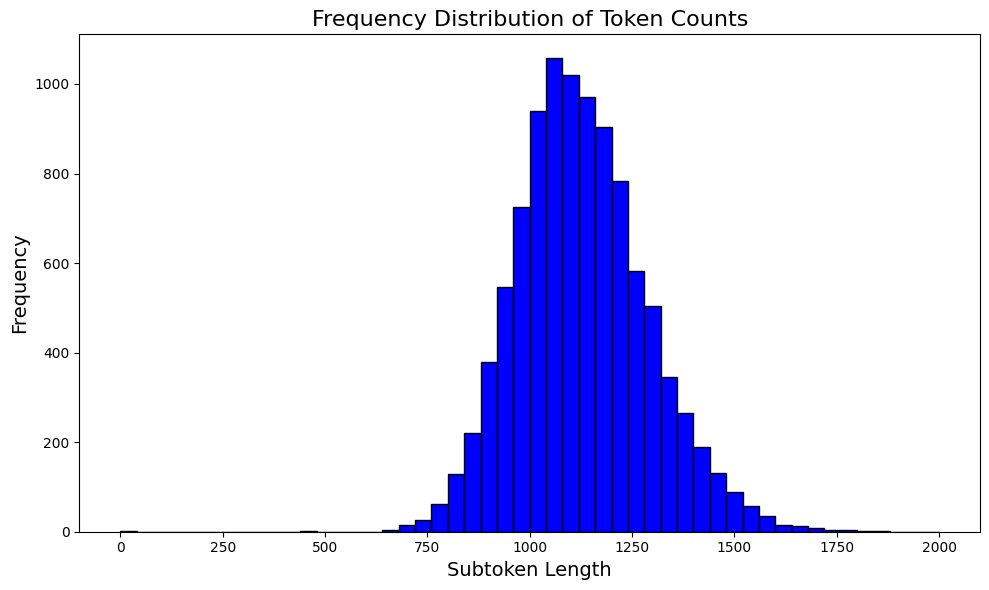

In [20]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'polished_dial'
df['token_count'] = df['polished_dial'].apply(count_tokens)

# 6. Plot the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(df['token_count'], bins=50, range=(0, 2000), color='blue', edgecolor='black')

# 7. Set the title and labels
plt.title('Frequency Distribution of Token Counts', fontsize=16)
plt.xlabel('Subtoken Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 8. Save the plot as an image
plt.tight_layout()
plt.savefig('token_count_histogram.png')

# 9. Show the plot
plt.show()

**Calculating the frequency of TARGET**

In [21]:
# 1. Convert all entries in 'Polished Note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
df['Polished Note'] = df['Polished Note'].astype(str).fillna('')

# 2. Remove newline characters from the 'polished_dial' column
df['Polished Note'] = df['Polished Note'].str.replace('\n', '')
df['Polished Note'] = df['Polished Note'].str.replace('*', '')

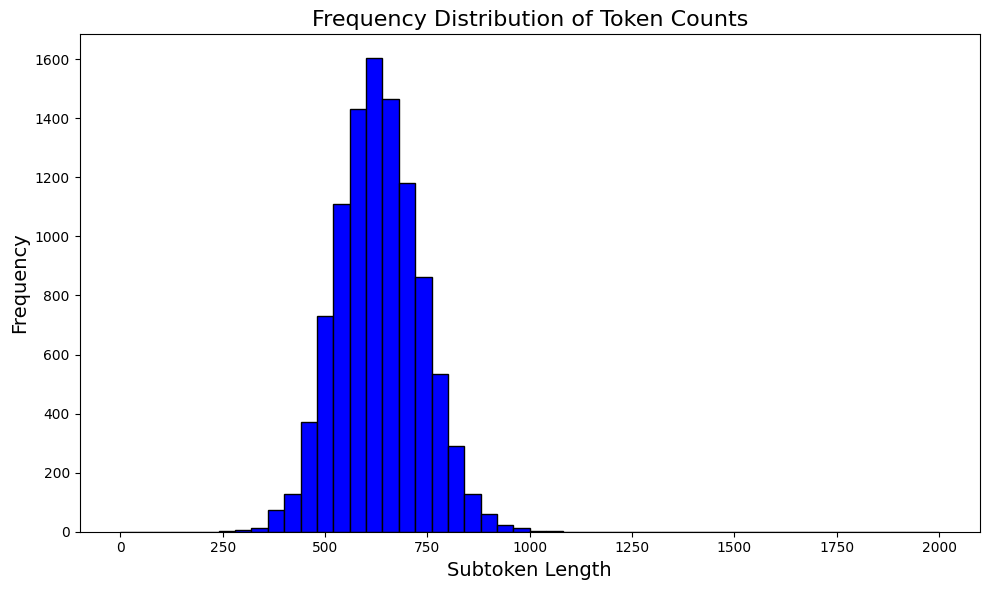

In [22]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'polished_dial'
df['token_count'] = df['Polished Note'].apply(count_tokens)

# 6. Plot the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(df['token_count'], bins=50, range=(0, 2000), color='blue', edgecolor='black')

# 7. Set the title and labels
plt.title('Frequency Distribution of Token Counts', fontsize=16)
plt.xlabel('Subtoken Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 8. Save the plot as an image
plt.tight_layout()
plt.savefig('token_count_histogram_for_TARGET.png')

# 9. Show the plot
plt.show()

**Calculate the avg of turns**

In [23]:
# 1. Convert all entries in 'polished_dial' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\paper\\total_data.csv", sep = "|")
df['polished_dial'] = df['polished_dial'].astype(str).fillna('')

# 2. Function to count the number of turns in a dialog
def count_turns(text):
    # Split the text by speaker tags to identify turns
    turns = text.split('[')
    # Exclude any empty splits and count the rest
    num_turns = len([turn for turn in turns if turn.strip()])
    return num_turns

# 3. Apply the turn counting function to each row in 'polished_dial'
df['turn_count'] = df['polished_dial'].apply(count_turns)

# 4. Calculate the average number of turns per dialog
avg_turn_count = df['turn_count'].mean()

# 5. Print the average number of turns
print(f"Average number of turns per dialog: {avg_turn_count:.2f}")


Average number of turns per dialog: 47.45
